In [1]:
import numpy as np
np.random.seed(42)

N = 2000
X = np.random.uniform(-3, 3, (N, 3))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]

# Nonlinear deterministic function
Y = np.sin(x1) + x2**2 + np.log(1 + np.abs(x3)) + 0.5 * x1 * x3
Y = Y.reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (2000, 3)
Y shape: (2000, 1)


In [3]:
import torch
import torch.nn as nn

X_pt = torch.tensor(X, dtype=torch.float32)
Y_pt = torch.tensor(Y, dtype=torch.float32)

W1 = torch.randn(3, 64) * 0.1; W1.requires_grad_(True)
b1 = torch.zeros(1, 64);       b1.requires_grad_(True)
W2 = torch.randn(64, 32) * 0.1; W2.requires_grad_(True)
b2 = torch.zeros(1, 32);        b2.requires_grad_(True)
W3 = torch.randn(32, 1) * 0.1;  W3.requires_grad_(True)
b3 = torch.zeros(1, 1);         b3.requires_grad_(True)

learning_rate = 0.05
epochs = 1000
losses = []

for epoch in range(epochs):
    Z1 = torch.mm(X_pt, W1) + b1
    A1 = torch.relu(Z1)
    Z2 = torch.mm(A1, W2) + b2
    A2 = torch.relu(Z2)
    Z3 = torch.mm(A2, W3) + b3
    A3 = Z3

    loss = torch.mean((A3 - Y_pt) ** 2)
    losses.append(loss.item())
    loss.backward()

    with torch.no_grad():
        W1.data -= learning_rate * W1.grad
        b1.data -= learning_rate * b1.grad
        W2.data -= learning_rate * W2.grad
        b2.data -= learning_rate * b2.grad
        W3.data -= learning_rate * W3.grad
        b3.data -= learning_rate * b3.grad

        W1.grad.zero_()
        b1.grad.zero_()
        W2.grad.zero_()
        b2.grad.zero_()
        W3.grad.zero_()
        b3.grad.zero_()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

predictions = A3.detach().numpy()

Epoch 100/1000 - Loss: 2.6528
Epoch 200/1000 - Loss: 0.8931
Epoch 300/1000 - Loss: 0.6154
Epoch 400/1000 - Loss: 0.4981
Epoch 500/1000 - Loss: 0.4175
Epoch 600/1000 - Loss: 0.3334
Epoch 700/1000 - Loss: 0.2770
Epoch 800/1000 - Loss: 0.2322
Epoch 900/1000 - Loss: 0.1984
Epoch 1000/1000 - Loss: 0.1727


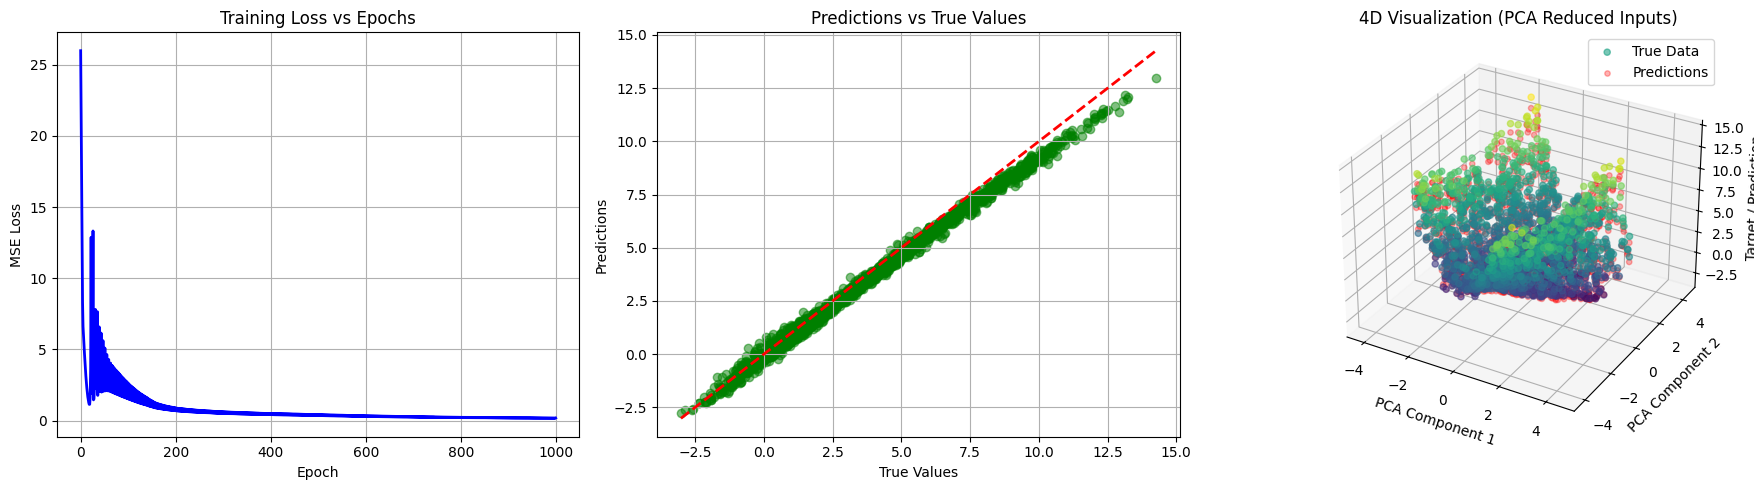

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(18, 5))

# Plot 1: Loss vs Epochs
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(losses, color='blue', linewidth=2)
ax1.set_title("Training Loss vs Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True)

# Plot 2: Predictions vs True Values
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(Y, predictions, alpha=0.5, color='green')
ax2.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
ax2.set_title("Predictions vs True Values")
ax2.set_xlabel("True Values")
ax2.set_ylabel("Predictions")
ax2.grid(True)

# Plot 3: 4D Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
sc = ax3.scatter(X_pca[:, 0], X_pca[:, 1], Y.flatten(), c=Y.flatten(), cmap='viridis', alpha=0.6, label='True Data')
ax3.scatter(X_pca[:, 0], X_pca[:, 1], predictions.flatten(), color='red', alpha=0.3, s=15, label='Predictions')
ax3.set_title("4D Visualization (PCA Reduced Inputs)")
ax3.set_xlabel("PCA Component 1")
ax3.set_ylabel("PCA Component 2")
ax3.set_zlabel("Target / Prediction")
ax3.legend()

plt.tight_layout()
plt.show()